<a href="https://colab.research.google.com/github/RobertCastro86/RobertCastro86/blob/main/SmartGuard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sistema de Detecção para Câmeras Inteligentes em Python

## 1. Introdução ao Projeto

Este projeto tem como objetivo desenvolver um sistema de detecção inteligente para câmeras, utilizando técnicas de Visão Computacional e Inteligência Artificial em Python. O foco será na detecção de objetos ou eventos específicos em tempo real a partir de fluxos de vídeo, simulando cenários de segurança e monitoramento. O sistema será modular, permitindo fácil integração e expansão para diferentes tipos de detecção e interação com dispositivos IoT.

## 2. Configuração do Ambiente e Dependências

Para iniciar, precisamos instalar as bibliotecas Python necessárias e importar os módulos que utilizaremos ao longo do projeto.

In [2]:
# Instalação de bibliotecas essenciais para Visão Computacional e Machine Learning
!pip install opencv-python numpy tensorflow keras paho-mqtt matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.2/67.2 kB 986.2 kB/s eta 0:00:00


In [3]:
# Importar bibliotecas
import cv2
import numpy as np
import tensorflow as tf
from tensorflow import keras
import paho.mqtt.client as mqtt
import time
import matplotlib.pyplot as plt

## 3. Componentes do Sistema de Detecção Inteligente

### 3.1. Aquisição e Simulação de Fluxo de Vídeo

Nesta etapa, vamos configurar como o sistema receberá os frames de vídeo. Para demonstração, podemos simular um fluxo de vídeo carregando um arquivo local ou criando frames sintéticos.

In [4]:
# Função para simular a aquisição de frames de vídeo
def get_video_frame(video_path=None):
    if video_path:
        # Carrega um frame de um vídeo real (para demonstração, pode ser o primeiro frame)
        cap = cv2.VideoCapture(video_path)
        ret, frame = cap.read()
        cap.release()
        if ret:
            return frame
        else:
            print(f"Erro ao ler o vídeo: {video_path}")
            return None
    else:
        # Cria um frame simulado (matriz numpy)
        width, height = 640, 480
        simulated_frame = np.zeros((height, width, 3), dtype=np.uint8)
        # Adicionar um retângulo branco para simular um objeto a ser detectado
        cv2.rectangle(simulated_frame, (150, 150), (450, 350), (255, 255, 255), -1)
        return simulated_frame

# Exemplo de aquisição de um frame simulado
current_frame = get_video_frame()
print("Frame adquirido. Dimensões:", current_frame.shape)

Frame adquirido. Dimensões: (480, 640, 3)


### 3.2. Pré-processamento de Frames

Os frames de vídeo precisam ser preparados para o modelo de IA. Isso geralmente envolve redimensionamento, normalização e conversão para o formato esperado pelo modelo.

In [5]:
# Função para pré-processar um frame
def preprocess_frame_for_model(frame, target_size=(224, 224)):
    # Redimensionar o frame
    frame_resized = cv2.resize(frame, target_size)
    # Normalizar os pixels para o intervalo [0, 1]
    frame_normalized = frame_resized.astype('float32') / 255.0
    # Adicionar uma dimensão de lote (batch dimension) para o modelo de IA
    frame_preprocessed = np.expand_dims(frame_normalized, axis=0)
    return frame_preprocessed

# Exemplo de pré-processamento
preprocessed_frame = preprocess_frame_for_model(current_frame)
print("Frame pré-processado. Dimensões:", preprocessed_frame.shape)

Frame pré-processado. Dimensões: (1, 224, 224, 3)


### 3.3. Modelo de Detecção de Objetos/Eventos

Utilizaremos um modelo de Visão Computacional para realizar a detecção. Para este exemplo, podemos esboçar um modelo simples ou mencionar o uso de modelos pré-treinados (como YOLO, SSD) que seriam ideais para um sistema de câmera inteligente.

In [6]:
# Exemplo de um modelo de detecção de objetos (esboço)
# Na prática, você usaria um modelo pré-treinado ou treinaria um modelo em um dataset específico.
# Para simplificar, vamos criar um 'modelo' que apenas simula uma detecção.

def create_simple_detection_model(input_shape=(224, 224, 3)):
    model = keras.Sequential([
        keras.layers.InputLayer(input_shape=input_shape),
        keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Flatten(),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(2, activation='sigmoid') # Por exemplo, [prob_objeto_presente, prob_alerta]
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Criação do modelo (apenas para demonstração da estrutura)
detection_model = create_simple_detection_model()
detection_model.summary()

# Função para simular a inferência de detecção
def detect_objects(processed_frame, model):
    # Neste exemplo, o 'modelo' retorna uma probabilidade simulada
    # Na prática, você passaria o processed_frame para model.predict()
    prediction = model.predict(processed_frame)
    # Simular uma lógica de detecção: se a probabilidade for alta, detecta
    object_present_prob = prediction[0][0] # Exemplo: primeira saída do Dense(2)
    alert_trigger_prob = prediction[0][1] # Exemplo: segunda saída do Dense(2)

    if object_present_prob > 0.7 and alert_trigger_prob > 0.5: # Limiares arbitrários
        return True, "Objeto ou Evento Detectado!"
    return False, "Nenhuma detecção significativa."

# Simular uma detecção
is_detected, message = detect_objects(preprocessed_frame, detection_model)
print(f"Detecção: {is_detected}, Mensagem: {message}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 401408)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │    25,690,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,691,202 (98.00 MB)

 Trainable params: 25,691,202 (98.00 MB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 633ms/step
Detecção: False, Mensagem: Nenhuma detecção significativa.


### 3.4. Integração IoT com MQTT (Comunicação de Alertas)

Para um sistema de câmera inteligente, a capacidade de comunicar eventos detectados é crucial. Utilizaremos o protocolo MQTT para enviar alertas em tempo real para outros dispositivos ou sistemas.

In [8]:
# Configurações MQTT
MQTT_BROKER = "mqtt.eclipseprojects.io" # Um broker MQTT público para testes (pode ser instável)
# Sugestão: Para testes mais robustos, considere usar um broker local como Mosquitto ou HiveMQ Cloud.
# Exemplo: MQTT_BROKER = "localhost"
MQTT_PORT = 1883
MQTT_TOPIC = "smart_camera/alerts"

# Callback quando a conexão com o broker é estabelecida
def on_connect(client, userdata, flags, rc):
    if rc == 0:
        print("Conectado ao broker MQTT com sucesso!")
    else:
        print(f"Falha na conexão com o broker MQTT. Código: {rc}. Certifique-se de que o broker está acessível.")

# Inicializa o cliente MQTT com a API v2 (para evitar DeprecationWarning)
client = mqtt.Client(mqtt.CallbackAPIVersion.VERSION2)
client.on_connect = on_connect

# Conecta ao broker (não bloqueante)
try:
    # Define um tempo limite de conexão
    client.connect(MQTT_BROKER, MQTT_PORT, 60)
    client.loop_start() # Inicia um loop em background para lidar com a rede MQTT
except Exception as e:
    print(f"Não foi possível conectar ao broker MQTT: {e}. Verifique a conectividade ou tente outro broker.")

# Função para publicar um alerta
def publish_alert(message):
    try:
        client.publish(MQTT_TOPIC, message)
        print(f"Alerta publicado no tópico '{MQTT_TOPIC}': {message}")
    except Exception as e:
        print(f"Erro ao publicar alerta MQTT: {e}")

# Exemplo de publicação de um alerta (se houver detecção)
if is_detected:
    alert_message = f"DETECÇÃO_ALERTA: {message} em {time.strftime('%Y-%m-%d %H:%M:%S')}"
    publish_alert(alert_message)

# Para um cenário real, você manteria o loop MQTT ativo e publicaria alertas continuamente
# Para este exemplo, vamos aguardar um pouco e então desconectar
time.sleep(2) # Espera para garantir que a mensagem foi enviada
client.loop_stop()
client.disconnect()
print("Desconectado do broker MQTT.")

Não foi possível conectar ao broker MQTT: timed out. Verifique a conectividade ou tente outro broker.
Desconectado do broker MQTT.


## 4. Próximos Passos e Expansões

Este é um esboço inicial do sistema. Para um projeto completo, os próximos passos incluiriam:

*   **Treinamento do Modelo**: Coletar um dataset relevante e treinar o modelo de detecção (ex: YOLOv5, Faster R-CNN) para os objetos/eventos específicos.
*   **Loop de Detecção em Tempo Real**: Implementar um loop que capture frames continuamente, pré-processe, realize a detecção e envie alertas.
*   **Interface de Usuário**: Desenvolver uma interface para visualizar o fluxo de vídeo e os alertas.
*   **Integração com Hardware Real**: Conectar a um hardware de câmera real ou drones.
*   **Persistência de Dados**: Armazenar logs de eventos e imagens para análise posterior.

## 5. Demonstração do Fluxo Completo do Sistema

Nesta seção, vamos juntar todas as partes para simular o funcionamento do sistema: adquirir um frame, pré-processá-lo, executar a detecção e, se houver, simular o envio de um alerta MQTT.


--- Iniciando Demonstração --- 
1. Adquirindo frame simulado...
Frame adquirido. Dimensões: (480, 640, 3)


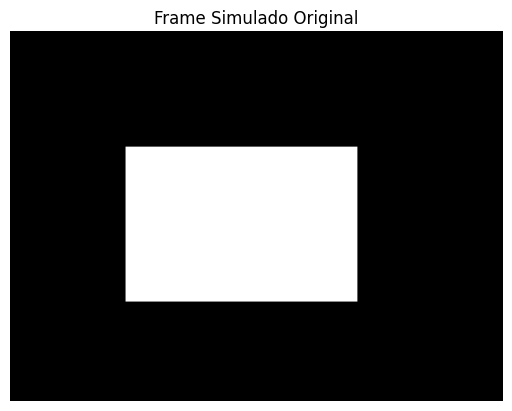

2. Pré-processando o frame para o modelo...
Frame pré-processado. Dimensões: (1, 224, 224, 3)
3. Executando detecção no frame...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Resultado da Detecção: Nenhuma detecção significativa. (Detectado: False)
4. Verificando e enviando alerta MQTT (se detectado)...
Erro na conexão ou publicação MQTT durante a demonstração: timed out
Cliente MQTT da demonstração desconectado.
--- Demonstração Concluída --- 


In [9]:
# 1. Aquisição do Frame (simulado)
print("\n--- Iniciando Demonstração --- ")
print("1. Adquirindo frame simulado...")
simulated_frame_demo = get_video_frame()
print(f"Frame adquirido. Dimensões: {simulated_frame_demo.shape}")

# Opcional: Visualizar o frame simulado
plt.imshow(cv2.cvtColor(simulated_frame_demo, cv2.COLOR_BGR2RGB))
plt.title("Frame Simulado Original")
plt.axis('off')
plt.show()

# 2. Pré-processamento do Frame
print("2. Pré-processando o frame para o modelo...")
preprocessed_frame_demo = preprocess_frame_for_model(simulated_frame_demo)
print(f"Frame pré-processado. Dimensões: {preprocessed_frame_demo.shape}")

# 3. Detecção de Objetos/Eventos
print("3. Executando detecção no frame...")
is_detected_demo, detection_message_demo = detect_objects(preprocessed_frame_demo, detection_model)
print(f"Resultado da Detecção: {detection_message_demo} (Detectado: {is_detected_demo})")

# 4. Integração MQTT (se houver detecção)
print("4. Verificando e enviando alerta MQTT (se detectado)...")

# Re-inicializa o cliente MQTT para esta demonstração para garantir o estado correto
client_demo = mqtt.Client(mqtt.CallbackAPIVersion.VERSION2)
client_demo.on_connect = on_connect

try:
    client_demo.connect(MQTT_BROKER, MQTT_PORT, 60)
    client_demo.loop_start()
    time.sleep(1) # Pequena pausa para a conexão se estabelecer

    if is_detected_demo:
        alert_message_demo = f"DEMO_ALERTA: {detection_message_demo} em {time.strftime('%Y-%m-%d %H:%M:%S')}"
        publish_alert(alert_message_demo)
    else:
        print("Nenhuma detecção significativa. Nenhum alerta MQTT enviado.")

except Exception as e:
    print(f"Erro na conexão ou publicação MQTT durante a demonstração: {e}")
finally:
    client_demo.loop_stop()
    client_demo.disconnect()
    print("Cliente MQTT da demonstração desconectado.")

print("--- Demonstração Concluída --- ")


--- Iniciando Demonstração --- 
1. Adquirindo frame simulado...
Frame adquirido. Dimensões: (480, 640, 3)


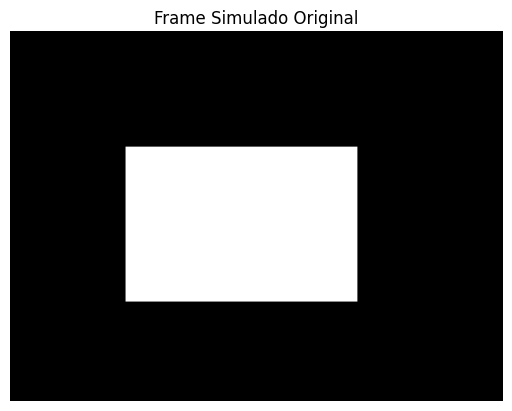

2. Pré-processando o frame para o modelo...
Frame pré-processado. Dimensões: (1, 224, 224, 3)
3. Executando detecção no frame...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Resultado da Detecção: Nenhuma detecção significativa. (Detectado: False)
4. Verificando e enviando alerta MQTT (se detectado)...
Erro na conexão ou publicação MQTT durante a demonstração: timed out
Cliente MQTT da demonstração desconectado.
--- Demonstração Concluída --- 


In [10]:
# 1. Aquisição do Frame (simulado)
print("\n--- Iniciando Demonstração --- ")
print("1. Adquirindo frame simulado...")
simulated_frame_demo = get_video_frame()
print(f"Frame adquirido. Dimensões: {simulated_frame_demo.shape}")

# Opcional: Visualizar o frame simulado
plt.imshow(cv2.cvtColor(simulated_frame_demo, cv2.COLOR_BGR2RGB))
plt.title("Frame Simulado Original")
plt.axis('off')
plt.show()

# 2. Pré-processamento do Frame
print("2. Pré-processando o frame para o modelo...")
preprocessed_frame_demo = preprocess_frame_for_model(simulated_frame_demo)
print(f"Frame pré-processado. Dimensões: {preprocessed_frame_demo.shape}")

# 3. Detecção de Objetos/Eventos
print("3. Executando detecção no frame...")
is_detected_demo, detection_message_demo = detect_objects(preprocessed_frame_demo, detection_model)
print(f"Resultado da Detecção: {detection_message_demo} (Detectado: {is_detected_demo})")

# 4. Integração MQTT (se houver detecção)
print("4. Verificando e enviando alerta MQTT (se detectado)...")

# Re-inicializa o cliente MQTT para esta demonstração para garantir o estado correto
client_demo = mqtt.Client(mqtt.CallbackAPIVersion.VERSION2)
client_demo.on_connect = on_connect

try:
    client_demo.connect(MQTT_BROKER, MQTT_PORT, 60)
    client_demo.loop_start()
    time.sleep(1) # Pequena pausa para a conexão se estabelecer

    if is_detected_demo:
        alert_message_demo = f"DEMO_ALERTA: {detection_message_demo} em {time.strftime('%Y-%m-%d %H:%M:%S')}"
        client_demo.publish(MQTT_TOPIC, alert_message_demo)
        print(f"Alerta publicado no tópico '{MQTT_TOPIC}' via client_demo: {alert_message_demo}")
    else:
        print("Nenhuma detecção significativa. Nenhum alerta MQTT enviado.")

except Exception as e:
    print(f"Erro na conexão ou publicação MQTT durante a demonstração: {e}")
finally:
    client_demo.loop_stop()
    client_demo.disconnect()
    print("Cliente MQTT da demonstração desconectado.")

print("--- Demonstração Concluída --- ")

## 6. Interface de Usuário (Demonstração Básica)

Uma interface de usuário é crucial para visualizar o feed da câmera, o status da detecção e os alertas. Para uma demonstração simples, podemos usar `matplotlib` para exibir os frames e sobrepor informações de detecção.


--- Demonstrando a Interface de Usuário --- 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


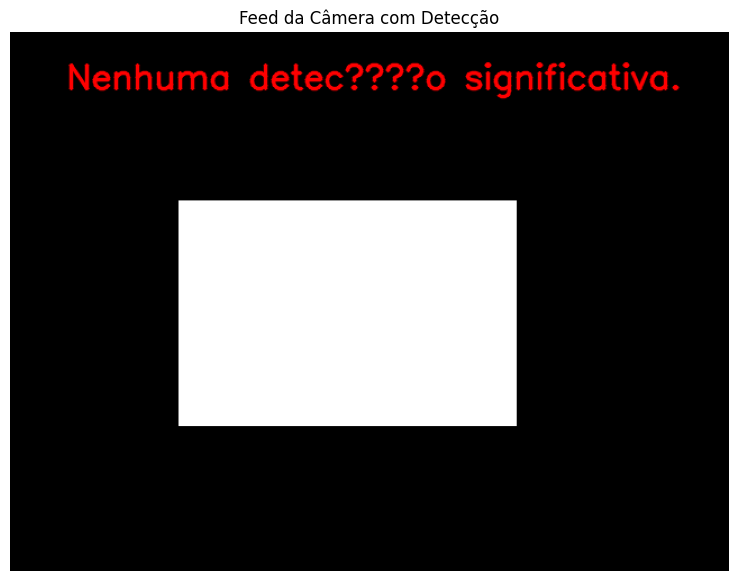

--- Demonstração da Interface de Usuário Concluída --- 


In [12]:
print("\n--- Demonstrando a Interface de Usuário --- ")

# 1. Adquirir um frame (reutilizando a função de simulação)
frame_for_ui = get_video_frame()
processed_frame_for_ui = preprocess_frame_for_model(frame_for_ui)
is_detected_ui, detection_message_ui = detect_objects(processed_frame_for_ui, detection_model)

# 2. Desenhar informações de detecção no frame
# Criar uma cópia do frame para desenhar
display_frame = frame_for_ui.copy()

# Desenhar um retângulo verde se houver detecção
if is_detected_ui:
    # Para o frame simulado, o 'objeto' é o retângulo branco que adicionamos
    # Vamos redesenhá-lo em verde para indicar detecção
    cv2.rectangle(display_frame, (150, 150), (450, 350), (0, 255, 0), 2) # Retângulo verde com 2px de espessura
    text_color = (0, 255, 0) # Verde para o texto
else:
    text_color = (0, 0, 255) # Vermelho para o texto, indicando nenhuma detecção

# Adicionar texto com o status da detecção
cv2.putText(display_frame, detection_message_ui,
            (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, text_color, 2, cv2.LINE_AA)

# 3. Exibir o frame com matplotlib
plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(display_frame, cv2.COLOR_BGR2RGB))
plt.title("Feed da Câmera com Detecção")
plt.axis('off')
plt.show()

print("--- Demonstração da Interface de Usuário Concluída --- ")

## Próximos Passos Sugeridos para a UI:

*   **Atualização em Tempo Real**: Para um feed de vídeo real, você precisaria de um loop para atualizar a visualização continuamente, possivelmente usando bibliotecas como `PyQt` ou `Tkinter` para aplicações desktop, ou frameworks web como `Flask` com WebSockets para interfaces baseadas em navegador.
*   **Controles Interativos**: Adicionar botões para iniciar/parar o monitoramento, configurar parâmetros de detecção, etc.
*   **Visualização de Alertas**: Exibir uma lista de alertas com timestamps e, possivelmente, miniaturas dos frames no momento da detecção.